In [31]:
# mount Google drive
from google.colab import drive
# load the liabries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde
# This will list the files in your specific folder
drive.mount('/content/drive')
# the list of airports we restirc ourselves to
airport_limit_list =["JFK","LAX","MIA","SFO","EWR","ORD","ATL","DFW","IAH",
"BOS","MCO","FLL","SEA","CLT","DEN","PHL","LAS","HNL","DTW","MSP","PHX","LGA","TPA",
"SLC","BWI","AUS","SAN","HOU","PDX","MDW","OAK","BNA","DCA","STL","DAL"]
# the airlines are already filterd to the ones only that we use.
source = "/content/drive/MyDrive/Datamining/Feature_ingeneered_Data/" # where we load the Data from
destination = "/content/drive/MyDrive/Datamining/Data_for_Model/" #where to put the Data, that is ready to be used in an ML Model.
output_file_name = "preprocessed.feather"
source_file = "feature_ingeneared.feather"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
df = pd.read_feather(source + source_file)
display(df)
target = "ArrDelayMinutes"

,Year,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,Origin,Dest,...,hist_dest_delay_7d,hist_dest_delay_30d,origin_yesterday_delay,origin_lastweek_delay,dest_yesterday_delay,dest_lastweek_delay,airline_yesterday_delay,airline_lastweek_delay,global_yesterday_delay,global_lastweek_delay
0,2014,1,1,3,2014-01-01,DL,N673DL,1110,PHX,DTW,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2014,1,1,3,2014-01-01,DL,N394DA,2324,SLC,ATL,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2014,1,1,3,2014-01-01,B6,N584JB,98,DEN,JFK,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2014,1,1,3,2014-01-01,DL,N960DN,1422,DEN,ATL,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2014,1,1,3,2014-01-01,AA,N3ALAA,1052,SFO,DFW,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1867366,2014,12,31,3,2014-12-31,UA,N210UA,383,HNL,DEN,...,22.557291,13.993797,9.243243,3.277778,34.982578,9.739496,23.044932,11.088359,21.980505,12.666294
1867367,2014,12,31,3,2014-12-31,AA,N5DEAA,142,HNL,LAX,...,17.662820,16.336445,9.243243,3.277778,43.340625,10.203065,21.802657,17.026549,21.980505,12.666294
1867368,2014,12,31,3,2014-12-31,DL,N586NW,1152,HNL,SFO,...,21.961377,34.378791,9.243243,3.277778,54.693617,23.696133,7.798573,7.646170,21.980505,12.666294
1867369,2014,12,31,3,2014-12-31,UA,N77525,1722,HNL,SFO,...,21.961377,34.378791,9.243243,3.277778,54.693617,23.696133,23.044932,11.088359,21.980505,12.666294


In [33]:
subsampling_rate_for_display = 3
#by ranomdization take 1 out of 3 records of the df, and save it to a copy version
df_copy = df.sample(frac=1/subsampling_rate_for_display)
display(df_copy)

,Year,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,Origin,Dest,...,hist_dest_delay_7d,hist_dest_delay_30d,origin_yesterday_delay,origin_lastweek_delay,dest_yesterday_delay,dest_lastweek_delay,airline_yesterday_delay,airline_lastweek_delay,global_yesterday_delay,global_lastweek_delay
1325308,2014,9,19,5,2014-09-19,WN,N273WN,186,EWR,MDW,...,5.645864,10.279519,9.891566,16.911765,8.503356,8.879195,17.868217,10.732267,14.245962,12.011127
4448,2014,1,2,4,2014-01-02,UA,N806UA,445,PHL,SFO,...,22.773869,22.773869,37.346939,0.000000,22.773869,0.000000,27.040884,0.000000,27.475768,0.000000
835990,2014,6,19,4,2014-06-19,UA,N823UA,456,IAH,LAS,...,19.909994,14.234785,31.620482,42.323529,27.863014,25.607306,36.144289,26.603682,30.219298,27.396240
1403765,2014,10,4,6,2014-10-04,UA,N39418,1279,ORD,LAX,...,15.355066,10.548689,31.532203,51.731343,15.654839,11.328125,19.334638,19.921875,21.041378,18.729978
458071,2014,4,7,1,2014-04-07,WN,N553WN,1707,DEN,PHX,...,15.826729,13.482428,10.117424,14.335616,14.103896,17.794286,16.811129,16.926638,13.176424,13.546719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925061,2014,7,6,7,2014-07-06,AA,N556AA,96,STL,DFW,...,12.503778,21.725067,4.341176,10.884615,5.602459,12.098976,8.642626,14.655005,7.737443,9.445716
1483460,2014,10,19,7,2014-10-19,UA,N518UA,514,JFK,SFO,...,16.023874,16.701268,4.134615,5.563953,3.481865,14.951020,6.725543,16.795339,4.195822,11.345653
1313510,2014,9,17,3,2014-09-17,AA,N3HMAA,1438,IAH,CLT,...,6.370202,10.081013,14.260274,9.953020,10.575000,2.951220,5.739796,7.466938,7.375261,6.526415
1287406,2014,9,12,5,2014-09-12,WN,N445WN,3621,STL,LAS,...,14.450685,10.895582,5.221154,8.543478,8.631111,10.226852,8.392707,13.649786,8.300370,13.657228


In [34]:
# function for desity scatter Plot
def desity_plot(df,feature_x,feature_y):
  x=df[feature_x]
  y=df[feature_y]
  xy = np.vstack([x,y])
  z = gaussian_kde(xy)(xy)

  # Sort the points by density, so that the densest points are plotted last
  idx = z.argsort()
  x, y, z = x[idx], y[idx], z[idx]

  plt.figure(figsize=(6, 5))
  plt.scatter(x, y, c=z, s=5, cmap='viridis')
  plt.colorbar(label='Density')
  plt.title("Scatter Plot Colored by Density")
  plt.xlabel(feature_x)
  plt.ylabel(feature_y)
  plt.show()


In [35]:
def categorical_desity(df, feature_x, feature_y):
    """
    Plots a violin plot for a categorical feature_x and continuous feature_y.
    Optimized for clarity and speed.
    """
    plt.figure(figsize=(12, 6))

    # Use seaborn's violinplot for the heavy lifting
    # palette='viridis' provides a clean, modern color scale
    # cut=0 ensures the density stays within the actual data range
    sns.violinplot(
        data=df,
        x=feature_x,
        y=feature_y,
        palette='viridis',
        inner='quartile',
        cut=0
    )

    plt.title(f'Distribution of {feature_y} by {feature_x}', fontsize=15)
    plt.xlabel(feature_x, fontsize=12)
    plt.ylabel(feature_y, fontsize=12)
    # cut the axis at y level 300
    plt.ylim(0, 300)
    # Rotate labels if they are long strings (like airline names)
    plt.xticks(rotation=45)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [36]:
from scipy.ndimage import gaussian_filter
def fast_density_scatter(df,feature_x,feature_y, bins=100, sigma=3, ax=None, **kwargs):
  """
  High-speed density scatter plot using 2D histogram + Gaussian blur.
  O(N) complexity vs O(N^2) for standard KDE.
  """
  x = df[feature_x]
  y = df[feature_y]
  n = len(df)

  # 1. Calculate the 2D histogram
  # We get the density 'h' and the bin edges
  h, xedges, yedges = np.histogram2d(x, y, bins=bins)

  # 2. Smooth the histogram with a Gaussian filter
  # sigma controls the 'spread' of the density
  h_smoothed = gaussian_filter(h, sigma=sigma)

  # 3. Map the smoothed density values back to the original points
  # We find which bin each (x, y) point belongs to
  x_idx = np.clip(np.digitize(x, xedges) - 1, 0, bins - 1)
  y_idx = np.clip(np.digitize(y, yedges) - 1, 0, bins - 1)

  # The density for each point is the value in its corresponding blurred bin
  densities = h_smoothed[x_idx, y_idx]

  # 4. Sort points by density so the brightest are on top
  idx = densities.argsort()
  x, y, densities = x[idx], y[idx], densities[idx]

  # 5. Plotting - Only create ONE figure
  fig, ax = plt.subplots(figsize=(8, 6))

  # Use ax.scatter instead of plt.scatter for better control
  scatter = ax.scatter(x, y, c=densities, **kwargs)

  # Add labels and colorbar using the ax object
  fig.colorbar(scatter, ax=ax, label='Relative Density')

  ax.set_title(f"Density Scatter: {feature_y} vs {feature_x}")
  ax.set_xlabel(feature_x)
  ax.set_ylabel(feature_y)

  # Set limits
  ax.set_ylim(0, 300)
  # find the max x
  max_x = df[feature_x].max()
  min_lim = min(max_x,600)
  ax.set_xlim(0, min_lim)
  plt.tight_layout()
  # plt.show() is optional in notebooks, but fine here if called once.
  plt.show()

In [50]:
cols_to_plot =["DaysToNearestHoliday","CRSTurnaroundTime","2h_prev_avg_delay","2h_prev_cum_count","Expected_Tournaround_time","Prev_flight_DelayMinutes","hist_dest_delay"]
categorical_to_plot = ["Airplane_already_at_airport","has_prev_flight","IsHoliday"]

/tmp/ipykernel_14566/3705257924.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


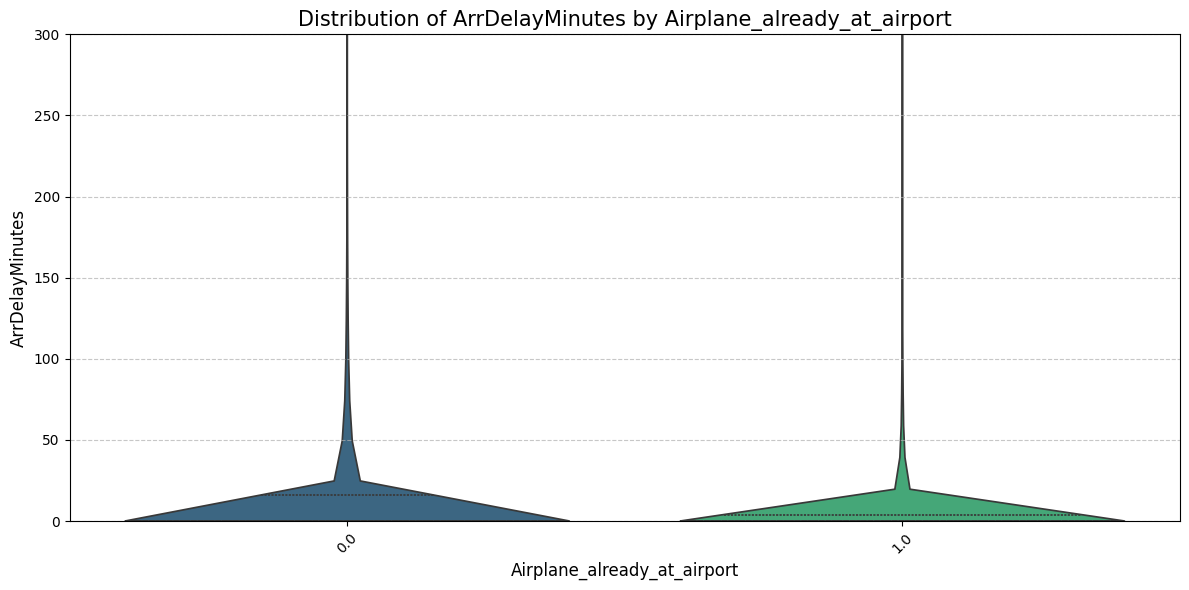

/tmp/ipykernel_14566/3705257924.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


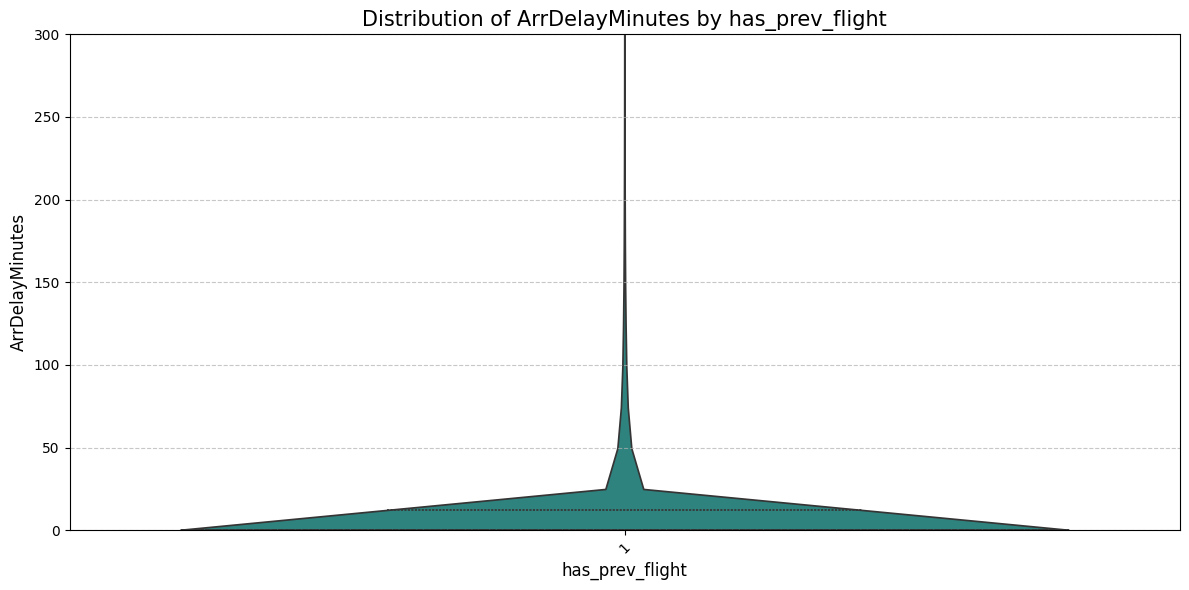

/tmp/ipykernel_14566/3705257924.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


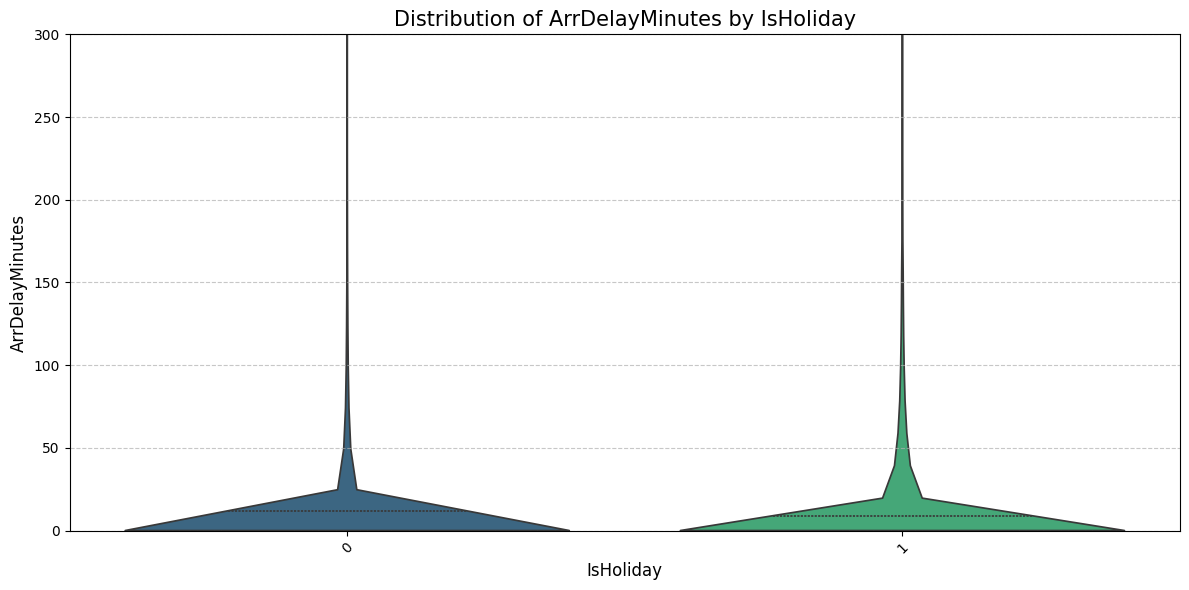

In [52]:
# plot every feature form the array with the target
for feature in categorical_to_plot:
  categorical_desity(df,feature,target)



In [39]:
# plot every feature form the array with the target
# for feature in cols_to_plot:
#   fast_density_scatter(df,feature,target)

In [40]:
def histogram_desity(df,feature_x,feature_y,bins=50):
  # filter out outliers, that have target over 300
  df_copy = df[df[feature_y]< 100][[feature_x,feature_y]].copy()
  df_copy = df_copy[df_copy[feature_x] < 300]

  x=df_copy[feature_x]
  y=df_copy[feature_y]
  # 3. 2D Histogram (Heatmap)
  plt.figure(figsize=(6, 5))
  plt.hist2d(x, y, bins=bins, cmap='inferno')
  plt.colorbar(label='Count in bin')
  plt.title("2D Histogram / Heatmap")
  plt.xlabel(feature_x)
  plt.ylabel(feature_y)
  plt.show()


In [48]:
def scatterplot(df,feature_x,feature_y):
  x=df_copy[feature_x]
  y=df_copy[feature_y]
  # 1. Standard Scatter Plot (Problematic one)
  plt.figure(figsize=(6, 5))
  plt.scatter(x, y, s=5)
  plt.title("Standard Scatter Plot (Overplotting)")
    # Set limits
  plt.ylim(0, 150)
  # find the max x
  max_x = df[feature_x].max()
  min_lim = min(max_x,600)
  plt.xlim(0, min_lim)
  plt.xlabel(feature_x)
  plt.ylabel(feature_y)
  plt.show("scatter_overplotted.png")


In [42]:
for feature in cols_to_plot:
  # histogram_desity(df,feature,target,200)
  pass

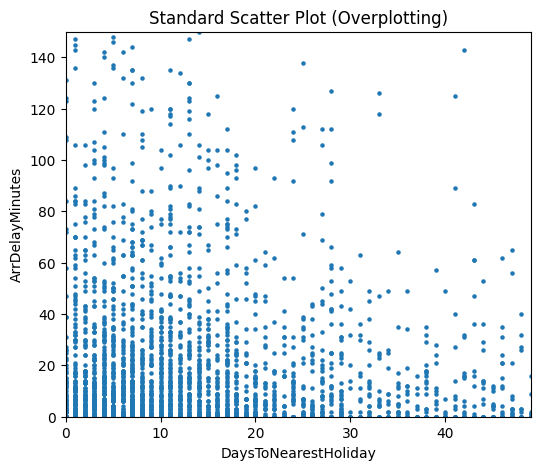

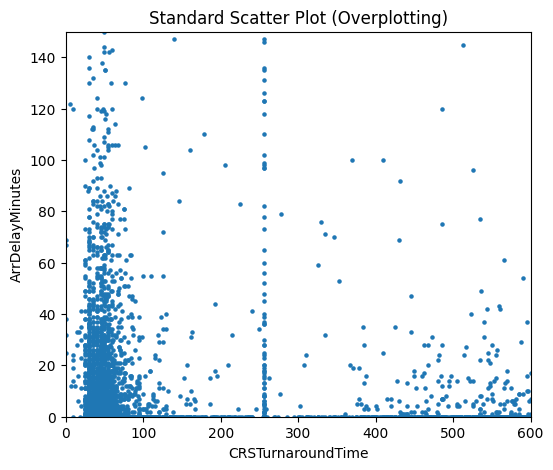

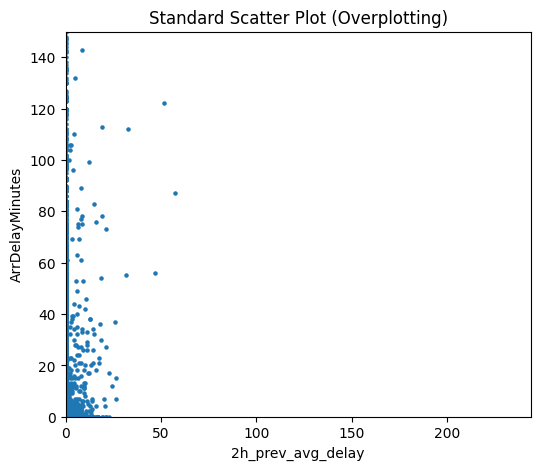

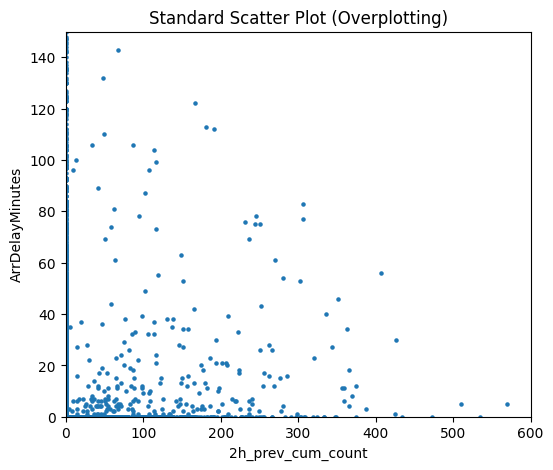

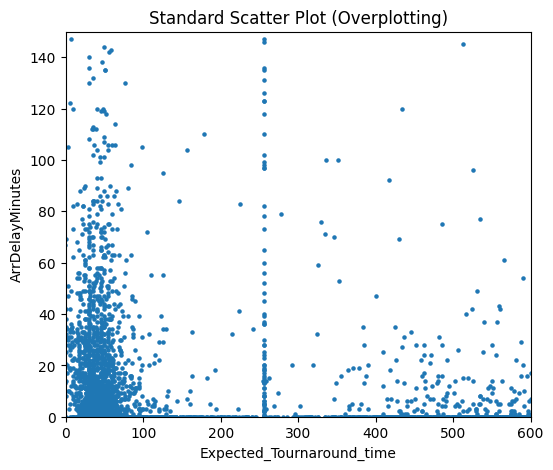

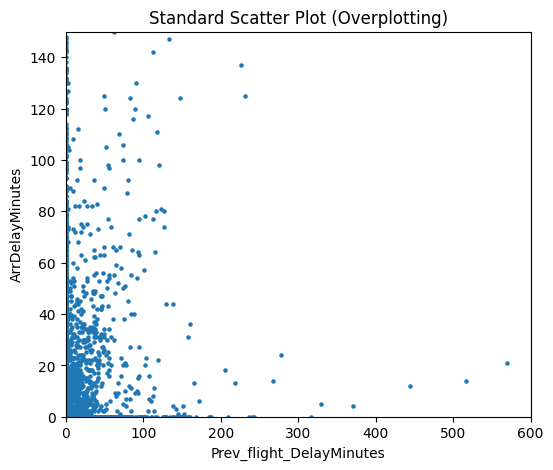

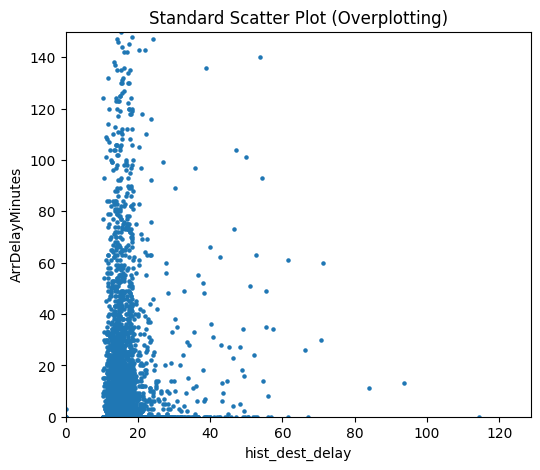

In [51]:
# subsampling to 5000 entries
df_copy = df.sample(n=5000)
for feature in cols_to_plot:
  scatterplot(df,feature,target)

